In [123]:
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import loguniform, randint, uniform
from sklearn.metrics import mean_squared_error as mse, mean_absolute_error as mae, root_mean_squared_error as rmse

import lightgbm as lgb
from lightgbm import LGBMRegressor
from lightgbm import Dataset
import torch

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from typing import List, Dict
import pickle
from pathlib import Path
from time import time

In [ ]:
def set_seed(seed=42):
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)
set_seed(42)

# Прогнозирование стоимости картин

## Подготовка пайплайна обучения модели для прогнозирования цены

### Загрузка данных

In [102]:
def load_data(file_path: str) -> pd.DataFrame:
    '''
    Функция для загрузки предобработанного датафрейма
    '''
    df = pd.read_csv(file_path, index_col=0)
    print(f'Входные размерности: {df.shape}')
    required_columns = ['saturation',
                      'bright',
                        'contrast',
                        'entropy',
                        'temperature',
                        'labels',
                        'distances_to_center',
                        'price',
                        'warmth',
                        'aspect_ratio',
                        'colorfulness']
    no_columns = list(filter(lambda x: True if x not in required_columns else False,
                             df.columns))
    print(f'Колонки, которые исключатся из обучающего датафрейма: {no_columns}')
    df_drop_columns = df.drop(columns=no_columns)
    df_dropna = df_drop_columns.dropna()
    df_dropna_drop_duplicates = df_dropna.drop_duplicates()
    print(f'Выходные размерности: {df_dropna_drop_duplicates.shape}\n')

    return df_dropna_drop_duplicates

### Предобработка

In [119]:
def prepare_features(df: pd.DataFrame) -> pd.DataFrame:
  if 'price' not in df.columns:
      raise ValueError('отсутствует колонка с ценой')

  target = np.log(df['price'].copy())
  features = df.drop(columns=['price']).copy()

  if 'labels' in features.columns:
      features['labels'] = features['labels'].astype('category')

  object_features = []
  for column in features.select_dtypes(include=['object', 'category']).columns:
      object_features.append(column)
  print(f'Категориоальные признаки: {object_features}')
  return features, target, object_features

### Разбиение на выборки

In [117]:
def data_train_test_split(target: np.ndarray | pd.Series,
                          features: np.ndarray | pd.DataFrame,
                          stratify_values: np.ndarray,
                          random_state: int = 42):
  X_train_val, x_test, y_train_val, y_test = train_test_split(features,
                                                                target,
                                                                test_size=0.2,
                                                                random_state=random_state,
                                                                shuffle=True,
                                                                stratify=stratify_values)
  X_train, x_val, y_train, y_val = train_test_split(X_train_val,
                                                      y_train_val,
                                                      test_size=0.25,
                                                      random_state=random_state,
                                                      shuffle=True,
                                                      stratify=X_train_val['labels'])
  print(f"Train: {X_train.shape[0]} картин")
  print(f"Validation: {x_val.shape[0]} картин")
  print(f"Test: {x_test.shape[0]} картин")
  print()
  return X_train, x_val, x_test, y_train, y_val, y_test

### Подбор гиперпараметров

In [118]:
def hyper_tunning(x_val: pd.DataFrame,
                  y_val: pd.DataFrame,
                  random_state: int = 42,
                  cv: int = 5):

    param_grid = {
    'learning_rate': loguniform(0.005, 0.3),
    'num_leaves': randint(31, 150),
    # 'n_estimators': randint(50, 500),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.6, 0.4),
    'reg_alpha': loguniform(0.01, 10),
    'reg_lambda': loguniform(0.01, 10),
    'min_child_samples': randint(5, 50),
    'boosting_type': ['gbdt'],
}
    model = LGBMRegressor(random_state=random_state)
    grid_search_model = RandomizedSearchCV(estimator=model,
                                           param_distributions=param_grid,
                                           random_state=random_state,
                                           refit=True,
                                           scoring='neg_root_mean_squared_error',
                                           cv=cv,
                                           n_iter=35,
                                           verbose=0)

    grid_search_model.fit(x_val, y_val)
    best_params = grid_search_model.best_params_
    best_model = grid_search_model.best_estimator_

    return best_model, dict(best_params)

### Обучение модели

In [106]:
def model_train(x_train, y_train, x_val, y_val, x_test, y_test,
                best_params: Dict,
                category_features: List,
                random_state: int = 42):

    train_ds = Dataset(data=x_train,
                    label=y_train,
                    categorical_feature=category_features)

    valid_ds = Dataset(data=x_val,
                       label=y_val,
                       reference=train_ds,
                       categorical_feature=category_features)

    test_ds = Dataset(data=x_test,
                      label=y_test,
                      categorical_feature=category_features)

    train_params = {
    'objective': 'regression',
    'metric': 'rmse',
    'seed': random_state,
    'boosting_type': 'gbdt',
    'verbose': -1,
    **best_params
    }

    eval_result = {}

    booster = lgb.train(
        params=train_params,
        train_set=train_ds,
        num_boost_round=1000,
        valid_sets=[train_ds, valid_ds, test_ds],
        valid_names=['train', 'valid', 'test'],
        callbacks=[
            lgb.log_evaluation(20),
            lgb.early_stopping(10, first_metric_only=True),
            lgb.record_evaluation(eval_result)
        ]
    )

    best_iteration = booster.best_iteration

    fig, ax = plt.subplots(2, 1, figsize=(10, 8))
    lgb.plot_metric(booster=eval_result,
                    metric='rmse',
                    ax=ax[0])
    lgb.plot_importance(booster, ax=ax[1])
    plt.tight_layout()
    plt.show()

    return booster, best_iteration


### Прогноз и метрики полученной модели

In [115]:
def forecaset_evaluate_model(model: lgb.Booster,
                            best_iteration,
                            x_train, y_train, x_val, y_val, x_test, y_test):
    y_train_pred = model.predict(data=x_train, num_iteration=best_iteration)
    y_valid_pred = model.predict(data=x_val, num_iteration=best_iteration)
    y_test_pred = model.predict(data=x_test, num_iteration=best_iteration)

    metrics = {
        "train_rmse": float(np.sqrt(mse(y_train, y_train_pred))),
        "valid_rmse": float(np.sqrt(mse(y_val, y_valid_pred))),
        "test_rmse": float(np.sqrt(mse(y_test, y_test_pred))),
        "train_mae": float(mae(y_train, y_train_pred)),
        "valid_mae": float(mae(y_val, y_valid_pred)),
        "test_mae": float(mae(y_test, y_test_pred)),
    }
    return metrics

### Сохранение модели

In [116]:
def save_model(model, path: str = r'/content/save_models/picture_price_model.pkl'):
    base_path = Path(path)
    base_path.parent.mkdir(parents=True, exist_ok=True)
    with open(base_path, 'wb') as write_file:
        pickle.dump(model, write_file)

In [114]:
def main_pipeline(data_path: str, model_save_path: str=r'/content/save_models/picture_price_model.pkl'):
  '''
  Функция для полного запуска пайплайна бустинга
  '''
  start = time()
  df = load_data(data_path)
  features, target, object_features = prepare_features(df)

  X_train, x_val, x_test, y_train, y_val, y_test = data_train_test_split(target, features, stratify_values=features['labels'].values)
  best_model, best_params = hyper_tunning(x_val, y_val)
  print(f'Лучшие параметры: {best_params}')

  final_model, best_iteration = model_train(X_train, y_train,
                                            x_val, y_val,
                                            x_test, y_test,
                                            best_params,
                                            category_features=object_features)
  metrics = forecaset_evaluate_model(model=final_model,
                                      best_iteration=best_iteration,
                                      x_train=X_train,
                                      y_train=y_train,
                                      x_val=x_val,
                                      y_val=y_val,
                                      x_test=x_test,
                                      y_test=y_test)
  print(f'Итоговые метрики на тестовой выборке: {metrics}')

  save_model(final_model, model_save_path)
  end = time()
  total_time = round(end-start, 2)
  print(f'Пайплайн отработал за {total_time} секунд')
  return final_model, metrics, X_train, x_val, x_test, y_train, y_val, y_test


## Запуск пайплана модели

In [97]:
df = pd.read_csv(r'/content/siglip-base_16934_clustered_df.csv', index_col=0)
df.head()

,aspect_ratio,colorfulness,saturation,bright,contrast,entropy,warmth,image_url,labels,distances_to_center,price
0,1.36,28.37,0.292,0.620,0.184,7.104,0.174,/content/christies_dataset/images/batch_0000/0...,2,0.585611,9221.878479
1,0.83,32.63,0.189,0.848,0.156,5.618,0.143,/content/christies_dataset/images/batch_0000/0...,5,0.505099,14345.144301
2,0.80,34.00,0.322,0.315,0.200,7.079,0.087,/content/christies_dataset/images/batch_0000/0...,23,0.527381,57380.577203
3,0.83,14.33,0.244,0.223,0.149,6.654,0.043,/content/christies_dataset/images/batch_0000/0...,23,0.511090,15984.589364
4,1.30,33.62,0.304,0.580,0.253,7.596,0.065,/content/christies_dataset/images/batch_0000/0...,4,0.623864,73775.027832


Входные размерности: (16934, 11)
Колонки, которые исключатся из обучающего датафрейма: ['image_url']
Выходные размерности: (16934, 10)

Категориоальные признаки: ['labels']
Train: 10160 картин
Validation: 3387 картин
Test: 3387 картин

Лучшие параметры: {'boosting_type': 'gbdt', 'colsample_bytree': np.float64(0.8545641645055122), 'learning_rate': np.float64(0.018111002276073877), 'min_child_samples': 36, 'num_leaves': 34, 'reg_alpha': np.float64(5.280796376895363), 'reg_lambda': np.float64(0.05595986878006084), 'subsample': np.float64(0.8231148769106889)}
Training until validation scores don't improve for 10 rounds
[20]	train's rmse: 1.82465	valid's rmse: 1.89234	test's rmse: 1.86429
[40]	train's rmse: 1.79005	valid's rmse: 1.8714	test's rmse: 1.84092
[60]	train's rmse: 1.7664	valid's rmse: 1.86146	test's rmse: 1.82995
[80]	train's rmse: 1.74695	valid's rmse: 1.85577	test's rmse: 1.82249
[100]	train's rmse: 1.73044	valid's rmse: 1.85321	test's rmse: 1.81917
[120]	train's rmse: 1.71659	

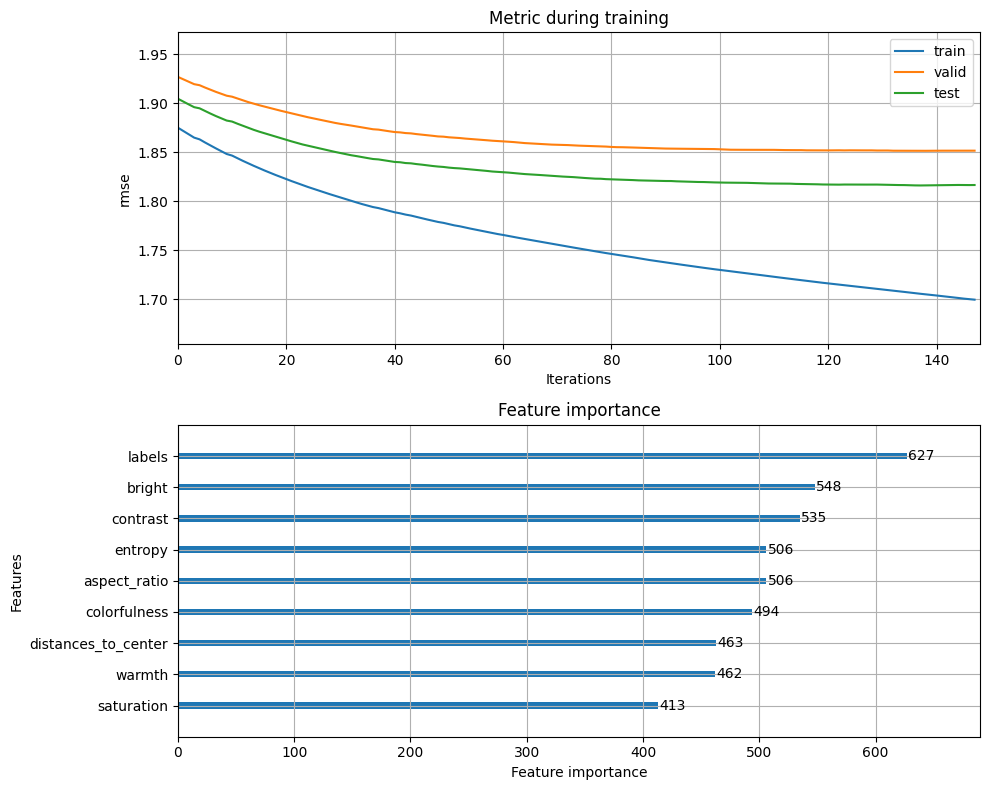

Итоговые метрики на тестовой выборке: {'train_rmse': 1.7053662136145624, 'valid_rmse': 1.8514458788305497, 'test_rmse': 1.8160440320282438, 'train_mae': 1.3391904349071082, 'valid_mae': 1.4538228248483993, 'test_mae': 1.4202090557823905}
Пайплайн отработал за 51.01 секунд


In [120]:
model, metrics, X_train, x_val, x_test, y_train, y_val, y_test = main_pipeline(data_path=r'/content/siglip-base_16934_clustered_df.csv')

# Тестирование гипотез